In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt

In [36]:
dim128_path = 'runs/base/exp1/model_weights.pth'
dim64_path = 'runs/base/exp3/model_weights.pth'
weights128 = torch.load(dim128_path)
weights64 = torch.load(dim64_path)

In [3]:
def visualize_features(weights, n=1000):
    features = []
    for key, value in weights.items():
        if 'readout' in key and 'feature' in key:
            features.append(value.cpu().squeeze().permute(1, 0))

    features = torch.cat(features)

    idcs = np.random.choice(features.shape[0], n)
    features = features[idcs]
    #features = (
    #    features - features.mean(axis=0)
    #) / features.std(axis=0)

    dists = (
        (features[None, :, :] - features[:, None, :])
        .pow(2)
        .sum(axis=-1)
        .sqrt()
    )
    i, j = np.tril_indices(n, k=-1)
    unique_dists = dists[i, j]

    plt.hist(unique_dists, bins=100, histtype='step', label=f'{features.shape[1]} dim embeddings', density=True)
    plt.xlabel('distance')
    plt.ylabel('density')
    print(f'std on {features.shape[1]}-dimensional features: {unique_dists.std()}')

std on 64-dimensional features: 0.1986222118139267
std on 128-dimensional features: 0.19652678072452545


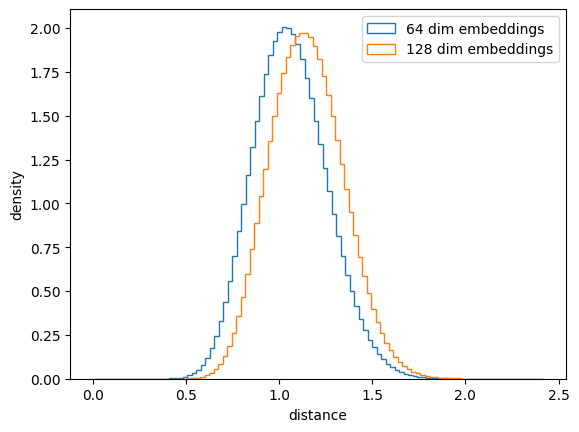

In [4]:
visualize_features(weights64, n=10000)
visualize_features(weights128, n=10000)
#plt.xlim(0, 50)
plt.legend()
plt.savefig('plots/embedding_distances.png')
plt.show()

In [37]:
features128 = []
for key, value in weights128.items():
    if 'readout' in key and 'feature' in key:
        features128.append(value.cpu().squeeze().permute(1, 0))
features128 = torch.cat(features128)

features64 = []
for key, value in weights64.items():
    if 'readout' in key and 'feature' in key:
        features64.append(value.cpu().squeeze().permute(1, 0))
features64 = torch.cat(features64)


In [38]:
(features128[:, :64] - features128[:, 64:]).flatten().abs().mean()

tensor(0.0674)

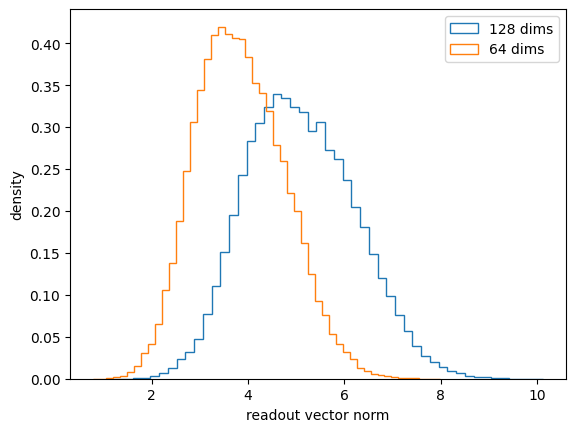

In [6]:
#normalized = (features - features.mean(axis=0)) / features.std(axis=0)
plt.hist(np.linalg.norm(features128, axis=1, ord=1), bins=50, histtype='step', density=True, label='128 dims')
plt.hist(np.linalg.norm(features64, axis=1, ord=1), bins=50, histtype='step', density=True, label='64 dims')
plt.ylabel('density')
plt.xlabel('readout vector norm')
plt.legend()
plt.savefig('plots/embedding_norms.png')
plt.show()

In [7]:
def visualize_cosine_sim(features, label, n=1000): 
    idcs = np.random.choice(features.shape[0], n)
    features = features[idcs]

    norm = torch.norm(features, dim=1)
    features = features / norm[:, None]
    cosine_sim = (
        (features[None, :, :] * features[:, None, :])
        .sum(dim=-1)
    )
    i, j = np.tril_indices(n, k=-1)
    cross_cos = cosine_sim[i, j]
    
    plt.hist(cross_cos, bins=50, histtype='step', density=True, label=label)

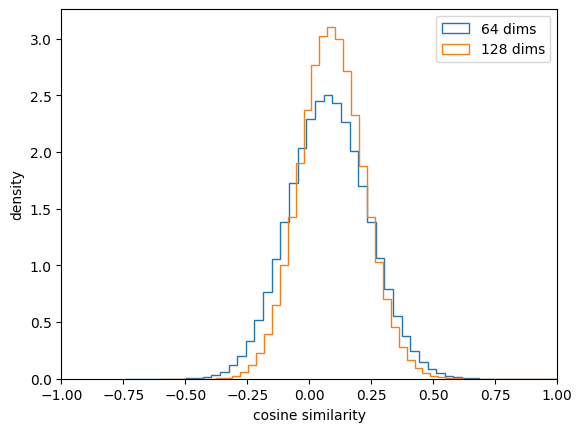

In [8]:
visualize_cosine_sim(features64, '64 dims', n=10000)
visualize_cosine_sim(features128, '128 dims', n=10000)
plt.xlabel('cosine similarity')
plt.ylabel('density')
plt.xlim(-1, 1)
plt.legend()
plt.savefig('plots/embedding_cosine_sim.png')
plt.show()

/tmp/ipykernel_119544/1439727890.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_bins = np.logspace(np.log10(data128.min()), np.log10(data128.max()), 500)


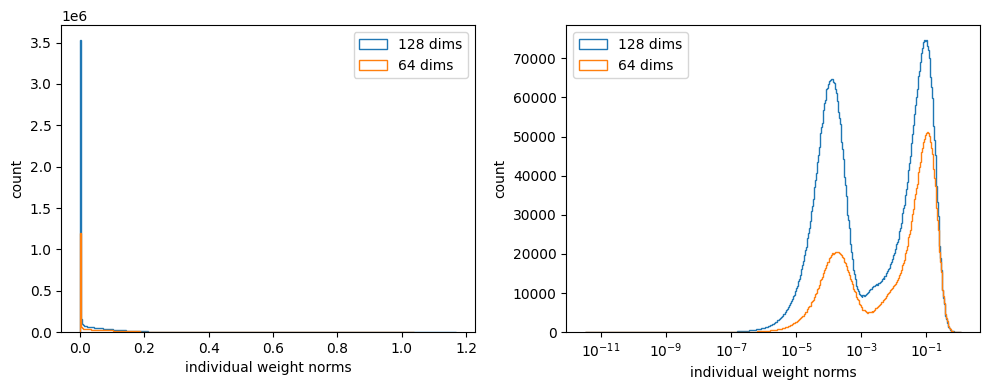

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4))

data128 = features128.flatten().abs()
data64 = features64.flatten().abs()

axs[0].hist(data128, bins=500, histtype='step', label='128 dims')
axs[0].hist(data64, bins=500, histtype='step', label='64 dims')
#axs[0].set_xlim(0, 0.25)
axs[0].legend()
axs[0].set_xlabel('individual weight norms')
axs[0].set_ylabel('count')

log_bins = np.logspace(np.log10(data128.min()), np.log10(data128.max()), 500)
axs[1].hist(data128, bins=log_bins, histtype='step', label='128 dims')
axs[1].hist(data64, bins=log_bins, histtype='step', label='64 dims')
#axs[1].set_yscale('log')
axs[1].set_xscale('log')
axs[1].legend()
axs[1].set_xlabel('individual weight norms')
axs[1].set_ylabel('count')

plt.tight_layout()
plt.savefig('plots/individual_weight_norm.png')
plt.show()

/tmp/ipykernel_3051/2858926392.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  log_bins = np.logspace(np.log10(data128.min()), np.log10(data128.max()), 50)


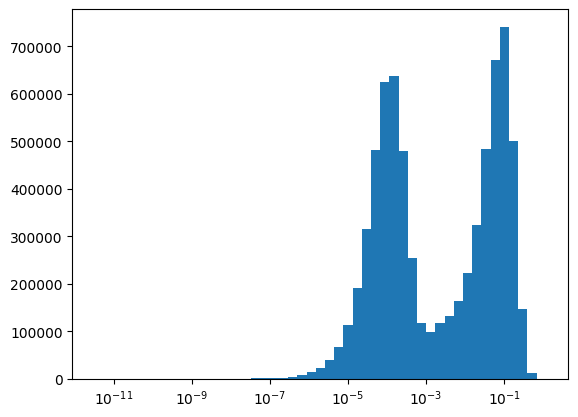

In [96]:
log_bins = np.logspace(np.log10(data128.min()), np.log10(data128.max()), 50)
plt.hist(features128.flatten().abs(), bins=log_bins)
plt.xscale('log')
plt.show()

In [23]:
def visualize_gaussian_distances(n=1000, k=64):
    features = torch.randn((n, k))
    features = (
        features - features.mean(axis=0)
    ) / features.std(axis=0)
    dists = (
        (features[None, :, :] - features[:, None, :])
        .pow(2)
        .sum(axis=-1)
        .sqrt()
    )
    i, j = np.tril_indices(n, k=-1)
    unique_dists = dists[i, j]
    
    plt.hist(unique_dists, bins=100, histtype='step', label=features.shape[1], density=True)
    plt.xlabel('distance')
    plt.ylabel('density')
    print(f'std on {features.shape[1]}-dimensional features: {unique_dists.std()}')

std on 1-dimensional features: 0.8534371256828308
std on 2-dimensional features: 0.9334908723831177
std on 4-dimensional features: 0.9681965112686157
std on 8-dimensional features: 0.9859932661056519
std on 16-dimensional features: 0.988209068775177
std on 32-dimensional features: 0.9959091544151306
std on 64-dimensional features: 0.9988622665405273
std on 128-dimensional features: 0.9958755970001221


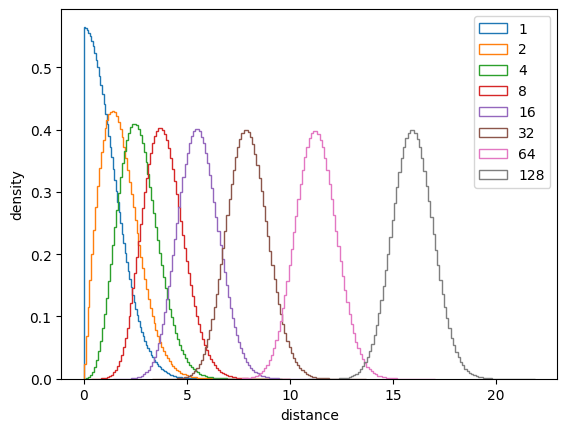

In [24]:
for k in [1, 2, 4, 8, 16, 32, 64, 128]:
    visualize_gaussian_distances(n=10000, k=k)
plt.legend()
plt.show()